# Sarcasm Detection Assignment 

My student ID is 277239, computed seed:

277239 mod 100000 = **77239**

From this seed I derived all the requirements:
- 77239 mod 3 = 1  →  smoothing values are **{0, 0.5, 2}**
- 77239 mod 4 = 3  →  ablation index **k = 3**
- 77239 mod 6 + 2 = 3  →  rare word threshold **t = 3**


In [15]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [16]:
seed = 77239
np.random.seed(seed)

all_data = []
myfile = open(r"C:\Users\ishiv\Downloads\Data\Sarcasm_Headlines_Dataset_v2.json", 'r')
for line in myfile:
    line = line.strip()
    if line != '':
        all_data.append(json.loads(line))
myfile.close()

data = pd.DataFrame(all_data)
print('total rows =', len(data))
print(data.head(3))

total rows = 28619
   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   

                                        article_link  
0  https://www.theonion.com/thirtysomething-scien...  
1  https://www.huffingtonpost.com/entry/donna-edw...  
2  https://www.huffingtonpost.com/entry/eat-your-...  


In [17]:
data = data.sample(frac=1, random_state=seed).reset_index(drop=True)

n  = len(data)
i1 = int(n * 0.70)
i2 = int(n * 0.85)

train = data.iloc[0:i1].reset_index(drop=True)
val   = data.iloc[i1:i2].reset_index(drop=True)
test  = data.iloc[i2:n].reset_index(drop=True)

print('train size =', len(train))
print('val size   =', len(val))
print('test size  =', len(test))

train size = 20033
val size   = 4293
test size  = 4293


## Task 1 – Tokenisation and Preprocessing

The preprocessing pipeline is split into five steps. Step 1) handles basic cleaning like converting to lowercase, stripping HTML tags, replacing tonal punctuation markers like !! or ?? with named tokens, then removing whatever punctuation is left. Step 2) deals with negation: for each negation word found, I count its vowels and prefix that many following tokens with NOT_. Step 3) removes stopwords, but any token already carrying a NOT_ prefix is left alone regardless. Step 4) generates unigrams and bigrams from the cleaned token list. Step 5) builds the vocabulary from the training set only and replaces any unseen token in validation or test with a special <UNK> marker.


In [18]:
negation_words = ['not', 'no', 'never', "don't", "didn't", "isn't", "wasn't"]

stopwords = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves",
             "you", "your", "yours", "yourself", "yourselves", "u",
             "he", "him", "his", "himself", "she", "her", "hers", "herself",
             "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
             "what", "which", "who", "whom", "this", "that", "these", "those",
             "am", "is", "are", "was", "were", "be", "been", "being", "while",
             "have", "has", "had", "having", "do", "does", "did", "doing",
             "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", 
             "of", "at", "by", "for", "with", "about", "against", "between", "into",
             "through", "during", "before", "after", "above", "below", "to", "from",
             "up", "down", "in", "out", "on", "off", "over", "under", "very",
             "again", "further", "then", "once", "here", "there",  "more", "most",
             "when", "where", "why", "how", "all", "any", "both", "each", "few", 
             "other", "some", "such","only", "own", "same", "so", "than", "too", 
             "s", "t", "can", "will", "just", "don", "should", "now"]


In [19]:
# TASK 1 – PREPROCESSING  

#TRAIN headlines

train_tokens = []

for headline in train['headline']:

    # Step 1: Basic Cleaning 

    # 1a. make everything lowercase
    text = headline.lower()

    # 1b. remove HTML tags  
    text = re.sub(r'<.*?>', '', text)

    # 1c. sarcasm marker substitution
    text = re.sub(r'[?!]*[!][?]+[?!]*|[?!]*[?][!]+[?!]*', '[INT_MARK]', text)
    text = re.sub(r'!{2,}',   '[EXC_SEQ]', text)   # !! !!!
    text = re.sub(r'[?]{2,}', '[QUE_SEQ]', text)   # ?? ???
    text = re.sub(r'[.]{3,}', '[ELLIP]',   text)   # ...

    # 1d. protecting apostrophes inside the words before stripping punctuation
    text = re.sub(r"(?<=[a-z])'(?=[a-z])", 'APOS', text)

    # 1e. remove all remaining punctuation replace with a space
    text = re.sub(r'[^\w\s]', ' ', text)

    # 1f. restore the apostrophes we protected in 1d
    text = text.replace('APOS', "'")

    # 1g. tokenise
    word_list = re.findall(r"[\w']+|\[\w+\]", text)


    # Step 2: Negation Handling 

    after_neg = []
    tag_count = 0         

    for word in word_list:
        if tag_count > 0:
            after_neg.append('NOT_' + word)   
            tag_count = tag_count - 1
        elif word in negation_words:
            after_neg.append(word)             
            vowel_count = 0
            for letter in word:
                if letter in 'aeiou':
                    vowel_count = vowel_count + 1
            tag_count = vowel_count           
        else:
            after_neg.append(word)


    # Step 3: Stopword Removal 

    after_stop = []

    for word in after_neg:
        if word.startswith('NOT_'):
            after_stop.append(word)         
        elif word not in stopwords:
            after_stop.append(word)         


    # Step 4: Generate Unigrams + Bigrams 

    final = list(after_stop)               

    for k in range(len(after_stop) - 1):
        bigram = after_stop[k] + '_' + after_stop[k + 1]
        final.append(bigram)              

    train_tokens.append(final)

print('train headlines processed =', len(train_tokens))
print('example original  :', train['headline'].iloc[0])
print('example processed :', train_tokens[0])


#Validation headlines

val_tokens = []

for headline in val['headline']:

    # Step 1: Basic Cleaning
    text = headline.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[?!]*[!][?]+[?!]*|[?!]*[?][!]+[?!]*', '[INT_MARK]', text)
    text = re.sub(r'!{2,}',   '[EXC_SEQ]', text)
    text = re.sub(r'[?]{2,}', '[QUE_SEQ]', text)
    text = re.sub(r'[.]{3,}', '[ELLIP]',   text)
    text = re.sub(r"(?<=[a-z])'(?=[a-z])", 'APOS', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.replace('APOS', "'")
    word_list = re.findall(r"[\w']+|\[\w+\]", text)

    # Step 2: Negation Handling
    after_neg = []
    tag_count = 0
    for word in word_list:
        if tag_count > 0:
            after_neg.append('NOT_' + word)
            tag_count = tag_count - 1
        elif word in negation_words:
            after_neg.append(word)
            vowel_count = 0
            for letter in word:
                if letter in 'aeiou':
                    vowel_count = vowel_count + 1
            tag_count = vowel_count
        else:
            after_neg.append(word)

    # Step 3: Stopword Removal
    after_stop = []
    for word in after_neg:
        if word.startswith('NOT_'):
            after_stop.append(word)
        elif word not in stopwords:
            after_stop.append(word)

    # Step 4: Unigrams + Bigrams
    final = list(after_stop)
    for k in range(len(after_stop) - 1):
        bigram = after_stop[k] + '_' + after_stop[k + 1]
        final.append(bigram)

    val_tokens.append(final)

print('val headlines processed =', len(val_tokens))


#TEST headlines 

test_tokens = []

for headline in test['headline']:

    # Step 1: Basic Cleaning
    text = headline.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[?!]*[!][?]+[?!]*|[?!]*[?][!]+[?!]*', '[INT_MARK]', text)
    text = re.sub(r'!{2,}',   '[EXC_SEQ]', text)
    text = re.sub(r'[?]{2,}', '[QUE_SEQ]', text)
    text = re.sub(r'[.]{3,}', '[ELLIP]',   text)
    text = re.sub(r"(?<=[a-z])'(?=[a-z])", 'APOS', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.replace('APOS', "'")
    word_list = re.findall(r"[\w']+|\[\w+\]", text)

    # Step 2: Negation Handling
    after_neg = []
    tag_count = 0
    for word in word_list:
        if tag_count > 0:
            after_neg.append('NOT_' + word)
            tag_count = tag_count - 1
        elif word in negation_words:
            after_neg.append(word)
            vowel_count = 0
            for letter in word:
                if letter in 'aeiou':
                    vowel_count = vowel_count + 1
            tag_count = vowel_count
        else:
            after_neg.append(word)

    # Step 3: Stopword Removal
    after_stop = []
    for word in after_neg:
        if word.startswith('NOT_'):
            after_stop.append(word)
        elif word not in stopwords:
            after_stop.append(word)

    # Step 4: Unigrams + Bigrams
    final = list(after_stop)
    for k in range(len(after_stop) - 1):
        bigram = after_stop[k] + '_' + after_stop[k + 1]
        final.append(bigram)

    test_tokens.append(final)

print('test headlines processed =', len(test_tokens))

train headlines processed = 20033
example original  : the military can't come up with a name for its war against isis. we're here to help.
example processed : ['military', "can't", 'come', 'name', 'war', 'isis', "we're", 'help', "military_can't", "can't_come", 'come_name', 'name_war', 'war_isis', "isis_we're", "we're_help"]
val headlines processed = 4293
test headlines processed = 4293


In [20]:
# step 5: OOV handling

train_vocab = set()
for doc in train_tokens:
    for word in doc:
        train_vocab.add(word)

print('vocabulary size from training =', len(train_vocab))

def apply_unk(token_list, vocab):
    result = []
    for doc in token_list:
        new_doc = []
        for word in doc:
            if word in vocab:
                new_doc.append(word)
            else:
                new_doc.append('<UNK>')
        result.append(new_doc)
    return result

val_tokens  = apply_unk(val_tokens,  train_vocab)
test_tokens = apply_unk(test_tokens, train_vocab)
print('<UNK> substitution done for val and test')

vocabulary size from training = 135427
<UNK> substitution done for val and test


## Task 2 – Manual Feature Representation

Both feature matrices were built from scratch without using CountVectorizer or TfidfVectorizer. I started by calculating the document frequency of every token in the training set, then dropped any token appearing in fewer than 3 documents (t = 3 comes from my seed). The remaining vocabulary is sorted alphabetically. Tokens at prime-numbered positions (2, 3, 5, 7, 11 ...) each get their own dedicated column. Tokens at non-prime positions are all merged into a single column at index 0. TF-IDF is computed on top of this same vocabulary using a smoothed IDF formula to avoid division by zero. The top 10 tokens by document frequency were also reported, excluding stopwords and negation words.


In [21]:
# document frequency
doc_freq = {}
for doc in train_tokens:
    seen_in_this_doc = set()
    for word in doc:
        if word not in seen_in_this_doc:
            seen_in_this_doc.add(word)
            if word not in doc_freq:
                doc_freq[word] = 0
            doc_freq[word] = doc_freq[word] + 1

# drop tokens appearing in less than 3 documents
vocab_filtered = []
for word in doc_freq:
    if doc_freq[word] >= 3:
        vocab_filtered.append(word)

vocab_filtered.sort()
print('vocabulary size after rare-word filtering =', len(vocab_filtered))

vocabulary size after rare-word filtering = 11797


In [22]:
def prime(num):
    if num < 2:
        return False
    for x in range(2, int(num**0.5) + 1):
        if num % x == 0:
            return False
    return True

prime_words    = []
nonprime_words = []
position = 1
for word in vocab_filtered:
    if prime(position):
        prime_words.append(word)
    else:
        nonprime_words.append(word)
    position = position + 1

print('words at prime positions     =', len(prime_words))
print('words at non-prime positions =', len(nonprime_words))

prime_words_set    = set(prime_words)
nonprime_words_set = set(nonprime_words)

word_to_col = {}
for idx in range(len(prime_words)):
    word_to_col[prime_words[idx]] = idx + 1

total_cols = 1 + len(prime_words)
print('total feature columns =', total_cols)

words at prime positions     = 1413
words at non-prime positions = 10384
total feature columns = 1414


In [23]:
# building count matrix for train
count_train = np.zeros((len(train_tokens), total_cols))
for i in range(len(train_tokens)):
    for word in train_tokens[i]:
        if word in nonprime_words_set:
            count_train[i][0] = count_train[i][0] + 1
        elif word in prime_words_set:
            c = word_to_col[word]
            count_train[i][c] = count_train[i][c] + 1

# building count matrix for val
count_val = np.zeros((len(val_tokens), total_cols))
for i in range(len(val_tokens)):
    for word in val_tokens[i]:
        if word in nonprime_words_set:
            count_val[i][0] = count_val[i][0] + 1
        elif word in prime_words_set:
            c = word_to_col[word]
            count_val[i][c] = count_val[i][c] + 1

# building count matrix for test
count_test = np.zeros((len(test_tokens), total_cols))
for i in range(len(test_tokens)):
    for word in test_tokens[i]:
        if word in nonprime_words_set:
            count_test[i][0] = count_test[i][0] + 1
        elif word in prime_words_set:
            c = word_to_col[word]
            count_test[i][c] = count_test[i][c] + 1

print('count_train shape =', count_train.shape)
print('count_val   shape =', count_val.shape)
print('count_test  shape =', count_test.shape)

count_train shape = (20033, 1414)
count_val   shape = (4293, 1414)
count_test  shape = (4293, 1414)


In [24]:
#Task 2B: TF-IDF 

num_train_docs = len(train_tokens)
idf = np.zeros(total_cols)

np_df = 0
for doc in train_tokens:
    for word in doc:
        if word in nonprime_words_set:
            np_df = np_df + 1
            break                          # only count this doc once
idf[0] = np.log((num_train_docs + 1) / (np_df + 1)) + 1

for i in range(len(prime_words)):
    df_w = doc_freq.get(prime_words[i], 0)
    idf[i + 1] = np.log((num_train_docs + 1) / (df_w + 1)) + 1

tfidf_train = np.zeros_like(count_train)
for i in range(len(count_train)):
    total = count_train[i].sum()
    if total == 0:
        total = 1                          
    for j in range(count_train.shape[1]):
        tf = count_train[i][j] / total
        tfidf_train[i][j] = tf * idf[j]

tfidf_val = np.zeros_like(count_val)
for i in range(len(count_val)):
    total = count_val[i].sum()
    if total == 0:
        total = 1
    for j in range(count_val.shape[1]):
        tf = count_val[i][j] / total
        tfidf_val[i][j] = tf * idf[j]

print('tfidf_train shape =', tfidf_train.shape)
print('tfidf_val   shape =', tfidf_val.shape)

tfidf_test = np.zeros_like(count_test)
for i in range(len(count_test)):
    total = count_test[i].sum()
    if total == 0:
        total = 1
    for j in range(count_test.shape[1]):
        tf = count_test[i][j] / total
        tfidf_test[i][j] = tf * idf[j]

print('tfidf_test  shape =', tfidf_test.shape)


tfidf_train shape = (20033, 1414)
tfidf_val   shape = (4293, 1414)
tfidf_test  shape = (4293, 1414)


Top 10 tokens by document frequency:
1 .   new = 1144
2 .   trump = 981
3 .   man = 944
4 .   report = 411
5 .   year = 372
6 .   one = 356
7 .   day = 355
8 .   area = 354
9 .   woman = 348
10 .   says = 346


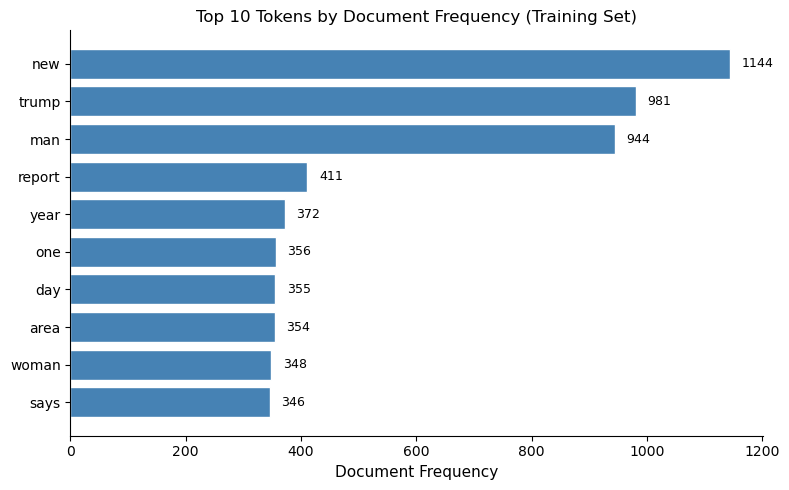

In [25]:
# Task 2C - top 10 df tokens 
df_list = []
for word in doc_freq:
    if word not in stopwords and word not in negation_words:
        df_list.append([doc_freq[word], word])
df_list.sort(reverse=True)

print('Top 10 tokens by document frequency:')
for i in range(10):
    print(i + 1, '.  ', df_list[i][1], '=', df_list[i][0])  # <-- closing ) was missing

# bar chart
top10_words  = [df_list[i][1] for i in range(10)]
top10_counts = [df_list[i][0] for i in range(10)]

# reversing cuz highest bar comes 1st
top10_words  = top10_words[::-1]
top10_counts = top10_counts[::-1]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(top10_words, top10_counts, color='steelblue', edgecolor='white')

# add count labels at bars end
for bar, count in zip(bars, top10_counts):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=9)

ax.set_xlabel('Document Frequency', fontsize=11)
ax.set_title('Top 10 Tokens by Document Frequency (Training Set)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Task 3 – Naïve Bayes Implementations

In this part, I implemented Multinomial and Bernoulli Naïve Bayes from scratch using log-space computations to avoid underflow. Both models were tested with alpha values of 0, 0.5, and 2. When alpha=0, zero log-probabilities are replaced with -1e9 to avoid undefined log(0), this keeps the math valid but alpha=0 is not recommended in practice. Differences across alpha values were small, so alpha=0.5 was selected as the best balance. Bernoulli outperformed Multinomial slightly, which makes sense for short headlines where word presence is more informative than frequency.

In [26]:
y_train = train['is_sarcastic'].values
y_val   = val['is_sarcastic'].values
y_test  = test['is_sarcastic'].values

In [27]:
# Task 3A: Multinomial Naïve Bayes 

def multinomial_nb_train(count_matrix, labels, alpha):
    log_prior = {}
    log_like  = {}
    for cls in [0, 1]:
        class_rows = [i for i in range(len(labels)) if labels[i] == cls]
        log_prior[cls] = np.log(len(class_rows) / len(labels))
        word_counts = np.zeros(count_matrix.shape[1])
        for i in class_rows:
            for j in range(count_matrix.shape[1]):
                word_counts[j] += count_matrix[i][j]
        if alpha > 0:
            word_counts = word_counts + alpha
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_log = np.log(word_counts / word_counts.sum())
        raw_log = np.where(np.isfinite(raw_log), raw_log, -1e9)
        log_like[cls] = raw_log
    return log_prior, log_like

def multinomial_nb_predict(count_matrix, log_prior, log_like):
    predictions = []
    for i in range(len(count_matrix)):
        score_0 = log_prior[0]
        score_1 = log_prior[1]
        with np.errstate(divide='ignore', invalid='ignore'):
            for j in range(count_matrix.shape[1]):
                score_0 = score_0 + count_matrix[i][j] * log_like[0][j]
                score_1 = score_1 + count_matrix[i][j] * log_like[1][j]
        if score_1 > score_0:
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)

print('Multinomial NB – validation results')
print()
for alpha in [0, 0.5, 2]:
    log_prior, log_like = multinomial_nb_train(count_train, y_train, alpha)
    predictions = multinomial_nb_predict(count_val, log_prior, log_like)
    acc = round(accuracy_score(y_val, predictions), 4)
    f1  = round(f1_score(y_val, predictions, average='macro'), 4)
    print('  alpha =', alpha, '  acc =', acc, '  macro f1 =', f1)
    if alpha == 0.5:
        saved_prior = log_prior
        saved_like  = log_like

print('\nMultinomial NB – test results')
test_preds_mnb = multinomial_nb_predict(count_test, saved_prior, saved_like)
print('  acc =', round(accuracy_score(y_test, test_preds_mnb), 4),
      '  macro f1 =', round(f1_score(y_test, test_preds_mnb, average='macro'), 4))

Multinomial NB – validation results

  alpha = 0   acc = 0.6003   macro f1 = 0.5753
  alpha = 0.5   acc = 0.5998   macro f1 = 0.5747
  alpha = 2   acc = 0.6007   macro f1 = 0.575

Multinomial NB – test results
  acc = 0.6203   macro f1 = 0.5945


In [28]:
# Task 3B: Bernoulli Naïve Bayes

def bernoulli_nb_train(count_matrix, labels, alpha):
    b_log_prior = {}
    b_log_yes   = {}
    b_log_no    = {}
    for cls in [0, 1]:
        class_rows = [i for i in range(len(labels)) if labels[i] == cls]
        nc = len(class_rows)
        b_log_prior[cls] = np.log(nc / len(labels))
        present = np.zeros(count_matrix.shape[1])
        for i in class_rows:
            for j in range(count_matrix.shape[1]):
                if count_matrix[i][j] > 0:
                    present[j] += 1
                    
        # Laplace smoothing
        prob_yes = (present + alpha) / (nc + 2 * alpha)
        with np.errstate(divide='ignore', invalid='ignore'):
            b_log_yes[cls] = np.log(prob_yes)
            b_log_no[cls]  = np.log(1 - prob_yes)
    return b_log_prior, b_log_yes, b_log_no

def bernoulli_nb_predict(count_matrix, b_log_prior, b_log_yes, b_log_no):
    predictions = []
    for i in range(len(count_matrix)):
        score_0 = b_log_prior[0]
        score_1 = b_log_prior[1]
        for j in range(count_matrix.shape[1]):
            present = 1 if count_matrix[i][j] > 0 else 0
            if present == 1:
                score_0 = score_0 + b_log_yes[0][j]
                score_1 = score_1 + b_log_yes[1][j]
            else:
                score_0 = score_0 + b_log_no[0][j]
                score_1 = score_1 + b_log_no[1][j]
        if score_1 > score_0:
            predictions.append(1)
        else:
            predictions.append(0)
    return np.array(predictions)

print('Bernoulli NB – validation results')
print()
for alpha in [0, 0.5, 2]:
    b_log_prior, b_log_yes, b_log_no = bernoulli_nb_train(count_train, y_train, alpha)
    predictions = bernoulli_nb_predict(count_val, b_log_prior, b_log_yes, b_log_no)
    acc = round(accuracy_score(y_val, predictions), 4)
    f1  = round(f1_score(y_val, predictions, average='macro'), 4)
    print('  alpha =', alpha, '  acc =', acc, '  macro f1 =', f1)
    if alpha == 0.5:
        saved_b_prior = b_log_prior
        saved_b_yes   = b_log_yes
        saved_b_no    = b_log_no
 
print('\nBernoulli NB – test results')
test_preds_bnb = bernoulli_nb_predict(count_test, saved_b_prior, saved_b_yes, saved_b_no)
print('  acc =', round(accuracy_score(y_test, test_preds_bnb), 4),
      '  macro f1 =', round(f1_score(y_test, test_preds_bnb, average='macro'), 4))


Bernoulli NB – validation results

  alpha = 0   acc = 0.601   macro f1 = 0.5776
  alpha = 0.5   acc = 0.6007   macro f1 = 0.5774
  alpha = 2   acc = 0.6005   macro f1 = 0.5758

Bernoulli NB – test results
  acc = 0.6198   macro f1 = 0.5952


## Task 4 – Numeric Meta-Features and Imputation

For this task I extracted eleven numeric features from each raw headline and its associated URL: word count, character length, average word length, exclamation count, question mark count, negation count, digit count, uppercase word count, sarcasm ratio, unique word count, and URL length.

After extracting all eleven features for train, validation, and test sets, I randomly injected 5% missing values into the training set using my seed, making sure at least one fell in the sarcasm ratio column as required.

For imputation I implemented two methods from scratch. Plain mean imputation fills each missing value with the overall column average. Class-conditional mean imputation fills it with the average from that specific class, so a missing value in a sarcastic headline gets filled with the sarcastic class mean rather than the overall mean. Class-conditional performed better because sarcastic and non-sarcastic headlines have noticeably different feature distributions, and mixing them into one mean loses that signal.

In [29]:
feature_names = ['word_count', 'char_length', 'avg_word_len', 'exclaim', 'question', 'neg_count', 'digits', 'uppercase_count',
                 'sarcasm_ratio', 'unique_word_count', 'url_length']

# extracting features for train
num_train = np.zeros((len(train), len(feature_names)))
for i in range(len(train)):
    headline          = train['headline'].iloc[i]
    words             = headline.split()
    word_count        = len(words)
    char_length       = len(headline)
    avg_word_len      = sum(len(w) for w in words) / len(words) if len(words) > 0 else 0
    neg_count         = 0
    for w in words:
        if w.lower() in negation_words:
            neg_count = neg_count + 1
    exclaim  = 0
    question = 0
    digits   = 0
    for ch in headline:
        if ch == '!':
            exclaim = exclaim + 1
        if ch == '?':
            question = question + 1
        if ch.isdigit():
            digits = digits + 1
    uppercase_count   = sum(1 for w in words if w.isupper() and len(w) > 1)
    sarcasm_ratio     = uppercase_count / word_count if word_count > 0 else 0.5
    unique_word_count = len(set(words))
    url_length        = len(train['article_link'].iloc[i])
    num_train[i] = [word_count, char_length, avg_word_len, exclaim,
                question, neg_count, digits, uppercase_count,
                sarcasm_ratio, unique_word_count, url_length]

# extracting features for validation
num_val = np.zeros((len(val), len(feature_names)))
for i in range(len(val)):
    headline          = val['headline'].iloc[i]
    words             = headline.split()
    word_count        = len(words)
    char_length       = len(headline)
    avg_word_len      = sum(len(w) for w in words) / len(words) if len(words) > 0 else 0
    neg_count         = 0
    for w in words:
        if w.lower() in negation_words:
            neg_count = neg_count + 1
    exclaim  = 0
    question = 0
    digits   = 0
    for ch in headline:
        if ch == '!':
            exclaim = exclaim + 1
        if ch == '?':
            question = question + 1
        if ch.isdigit():
            digits = digits + 1
    uppercase_count   = sum(1 for w in words if w.isupper() and len(w) > 1)
    sarcasm_ratio     = uppercase_count / word_count if word_count > 0 else 0.5
    unique_word_count = len(set(words))
    url_length        = len(val['article_link'].iloc[i])
    num_val[i] = [word_count, char_length, avg_word_len, exclaim,
              question, neg_count, digits, uppercase_count,
              sarcasm_ratio, unique_word_count, url_length]


# extracting features for test
num_test = np.zeros((len(test), len(feature_names)))
for i in range(len(test)):
    headline          = test['headline'].iloc[i]
    words             = headline.split()
    word_count        = len(words)
    char_length       = len(headline)
    avg_word_len      = sum(len(w) for w in words) / len(words) if len(words) > 0 else 0
    neg_count         = 0
    for w in words:
        if w.lower() in negation_words:
            neg_count = neg_count + 1
    exclaim  = 0
    question = 0
    digits   = 0
    for ch in headline:
        if ch == '!':
            exclaim = exclaim + 1
        if ch == '?':
            question = question + 1
        if ch.isdigit():
            digits = digits + 1
    uppercase_count   = sum(1 for w in words if w.isupper() and len(w) > 1)
    sarcasm_ratio     = uppercase_count / word_count if word_count > 0 else 0.5
    unique_word_count = len(set(words))
    url_length        = len(test['article_link'].iloc[i])
    num_test[i] = [word_count, char_length, avg_word_len, exclaim,
               question, neg_count, digits, uppercase_count,
               sarcasm_ratio, unique_word_count, url_length]
print('num_train shape =', num_train.shape)
print('num_val   shape =', num_val.shape)
print('num_test  shape =', num_test.shape)

num_train shape = (20033, 11)
num_val   shape = (4293, 11)
num_test  shape = (4293, 11)


In [30]:
# Task 4A – inject 5% missing values 

np.random.seed(seed)
num_train_missing = num_train.copy()

total_cells   = num_train_missing.shape[0] * num_train_missing.shape[1]
how_many_miss = int(0.05 * total_cells)

all_positions = []
for r in range(num_train_missing.shape[0]):
    for c in range(num_train_missing.shape[1]):
        all_positions.append((r, c))

np.random.shuffle(all_positions)
to_remove = all_positions[0:how_many_miss]

sar_col = feature_names.index('sarcasm_ratio')
found = False
for r, c in to_remove:
    if c == sar_col:
        found = True
if found == False:
    to_remove[0] = (0, sar_col)

for r, c in to_remove:
    num_train_missing[r][c] = np.nan

print('total missing values injected   =', int(np.isnan(num_train_missing).sum()))
print('missing in sarcasm_ratio column =', int(np.isnan(num_train_missing[:, sar_col]).sum()))

total missing values injected   = 11018
missing in sarcasm_ratio column = 1008


In [31]:
# Task 4B - mean imputation

imputed_mean = num_train_missing.copy()
for c in range(imputed_mean.shape[1]):
    good_vals = []
    for r in range(imputed_mean.shape[0]):
        if not np.isnan(imputed_mean[r][c]):
            good_vals.append(imputed_mean[r][c])
    col_mean = sum(good_vals) / len(good_vals)
    for r in range(imputed_mean.shape[0]):
        if np.isnan(imputed_mean[r][c]):
            imputed_mean[r][c] = col_mean

print('missing after mean imputation =', int(np.isnan(imputed_mean).sum()))

# Task 4B – class-conditional mean imputation
imputed_class = num_train_missing.copy()
for c in range(imputed_class.shape[1]):
    for cls in [0, 1]:
        good_vals = []
        for r in range(imputed_class.shape[0]):
            if y_train[r] == cls and not np.isnan(imputed_class[r][c]):
                good_vals.append(imputed_class[r][c])
        cls_mean = sum(good_vals) / len(good_vals)
        for r in range(imputed_class.shape[0]):
            if y_train[r] == cls and np.isnan(imputed_class[r][c]):
                imputed_class[r][c] = cls_mean

print('missing after class-conditional imputation =', int(np.isnan(imputed_class).sum()))

missing after mean imputation = 0
missing after class-conditional imputation = 0


In [32]:
# Gaussian NB 

# Kept as a function, called in Tasks 4, 5, and 6
def gaussian_nb_train(X, y):
    priors = {}
    means  = {}
    vars_  = {}
    for cls in [0, 1]:
        rows = []
        for i in range(len(y)):
            if y[i] == cls:
                rows.append(i)
        priors[cls] = len(rows) / len(y)
        class_data  = X[rows]
        means[cls]  = class_data.mean(axis=0)
        vars_[cls]  = class_data.var(axis=0) + 1e-9
    return priors, means, vars_


def gaussian_nb_predict(X, priors, means, vars_):
    preds = []
    for i in range(len(X)):
        best_cls   = -1
        best_score = -1e18
        for cls in [0, 1]:
            score = np.log(priors[cls])
            for f in range(X.shape[1]):
                mu  = means[cls][f]
                var = vars_[cls][f]
                score = score - 0.5 * np.log(2 * np.pi * var)
                score = score - ((X[i][f] - mu) ** 2) / (2 * var)
            if score > best_score:
                best_score = score
                best_cls   = cls
        preds.append(best_cls)
    return np.array(preds)


# Task 4C – comparing both imputation methods using Gaussian NB

p1, m1, v1 = gaussian_nb_train(imputed_mean, y_train)
pred_mean_imp = gaussian_nb_predict(num_val, p1, m1, v1)

p2, m2, v2 = gaussian_nb_train(imputed_class, y_train)
pred_class_imp = gaussian_nb_predict(num_val, p2, m2, v2)

acc_mean  = round(accuracy_score(y_val, pred_mean_imp),  4)
f1_mean   = round(f1_score(y_val, pred_mean_imp,  average='macro'), 4)
acc_class = round(accuracy_score(y_val, pred_class_imp), 4)
f1_class  = round(f1_score(y_val, pred_class_imp, average='macro'), 4)

print('Imputation comparison (Gaussian NB on validation set):')
print()
print('Method                     Accuracy   Macro F1')
print('_________________________________________________')
print(f'Mean imputation            {acc_mean}     {f1_mean}')
print(f'Class-conditional mean     {acc_class}     {f1_class}')

Imputation comparison (Gaussian NB on validation set):

Method                     Accuracy   Macro F1
_________________________________________________
Mean imputation            0.6543     0.6235
Class-conditional mean     0.6553     0.6249


## Task 5 – Outlier Detection

A small number of headlines are genuinely extremly long, or loaded with punctuation. These outliers skew Gaussian NB's mean and variance estimates, which makes the model less accurate on normal headlines.

I used the standard IQR rule: anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is treated as an outlier. Rather than deleting those rows, I clamped the values to the boundary. This way the class distribution stays exactly the same before and after treatment.


In [33]:
# Task 5A – compute IQR on training

clean_train = imputed_class.copy()

lower_bound = []
upper_bound = []

for c in range(clean_train.shape[1]):
    q1  = np.percentile(clean_train[:, c], 25)
    q3  = np.percentile(clean_train[:, c], 75)
    iqr = q3 - q1
    lower_bound.append(q1 - 1.5 * iqr)
    upper_bound.append(q3 + 1.5 * iqr)

outlier_count = 0
for r in range(len(clean_train)):
    for c in range(clean_train.shape[1]):
        if clean_train[r][c] < lower_bound[c] or clean_train[r][c] > upper_bound[c]:
            outlier_count = outlier_count + 1
            break

print('Rows with at least one outlier =', outlier_count)

# Task 5B – clamp outliers to the boundary

clamped_train = clean_train.copy()
for r in range(len(clamped_train)):
    for c in range(clamped_train.shape[1]):
        if clamped_train[r][c] < lower_bound[c]:
            clamped_train[r][c] = lower_bound[c]
        elif clamped_train[r][c] > upper_bound[c]:
            clamped_train[r][c] = upper_bound[c]

clamped_val = num_val.copy()
for r in range(len(clamped_val)):
    for c in range(clamped_val.shape[1]):
        if clamped_val[r][c] < lower_bound[c]:
            clamped_val[r][c] = lower_bound[c]
        elif clamped_val[r][c] > upper_bound[c]:
            clamped_val[r][c] = upper_bound[c]

clamped_test = num_test.copy()
for r in range(len(clamped_test)):
    for c in range(clamped_test.shape[1]):
        if clamped_test[r][c] < lower_bound[c]:
            clamped_test[r][c] = lower_bound[c]
        elif clamped_test[r][c] > upper_bound[c]:
            clamped_test[r][c] = upper_bound[c]

print()
print('Class distribution (unchanged by clamping because no rows were removed):')
print('class 0 =', int((y_train == 0).sum()))
print('class 1 =', int((y_train == 1).sum()))

p_before, m_before, v_before = gaussian_nb_train(imputed_class, y_train)
pred_before = gaussian_nb_predict(num_val, p_before, m_before, v_before)

p_after, m_after, v_after = gaussian_nb_train(clamped_train, y_train)
pred_after = gaussian_nb_predict(clamped_val, p_after, m_after, v_after)

print()
print('Effect of clamping on Gaussian NB (validation set):')
print()
print('State              Accuracy   Macro F1')
print('________________________________________')
print(f'Before clamping    {round(accuracy_score(y_val, pred_before), 4)}     {round(f1_score(y_val, pred_before, average="macro"), 4)}')
print(f'After  clamping    {round(accuracy_score(y_val, pred_after),  4)}     {round(f1_score(y_val, pred_after,  average="macro"), 4)}')

Rows with at least one outlier = 9255

Class distribution (unchanged by clamping because no rows were removed):
class 0 = 10530
class 1 = 9503

Effect of clamping on Gaussian NB (validation set):

State              Accuracy   Macro F1
________________________________________
Before clamping    0.6553     0.6249
After  clamping    0.6599     0.6554


## Task 6 – Scaling Study

The numeric features operate on very different scales, word count sits in the single digits to low thirties, character length can exceed a hundred, and sarcasm ratio always stays between 0 and 1. Gaussian NB models each feature as a normal distribution, and large differences in scale can distort those estimates.

I applied two scalers: MinMax scaling (maps everything to the 0–1 range) and standardisation (zero mean, unit variance). Both were fitted on the training set only and applied to validation, so there is no data leakage.


In [34]:
# MinMax scaling

col_min = []
col_max = []
for c in range(clamped_train.shape[1]):
    col_min.append(clamped_train[:, c].min())
    col_max.append(clamped_train[:, c].max())

train_minmax = np.zeros_like(clamped_train)
for r in range(clamped_train.shape[0]):
    for c in range(clamped_train.shape[1]):
        rng = col_max[c] - col_min[c]
        if rng == 0:
            train_minmax[r][c] = 0
        else:
            train_minmax[r][c] = (clamped_train[r][c] - col_min[c]) / rng

val_minmax = np.zeros_like(clamped_val)
for r in range(clamped_val.shape[0]):
    for c in range(clamped_val.shape[1]):
        rng = col_max[c] - col_min[c]
        if rng == 0:
            val_minmax[r][c] = 0
        else:
            val_minmax[r][c] = (clamped_val[r][c] - col_min[c]) / rng

test_minmax = np.zeros_like(clamped_test)
for r in range(clamped_test.shape[0]):
    for c in range(clamped_test.shape[1]):
        rng = col_max[c] - col_min[c]
        if rng == 0:
            test_minmax[r][c] = 0
        else:
            test_minmax[r][c] = (clamped_test[r][c] - col_min[c]) / rng

# Standardisation

col_mean = []
col_std  = []
for c in range(clamped_train.shape[1]):
    col_mean.append(clamped_train[:, c].mean())
    col_std.append(clamped_train[:, c].std())

train_standard = np.zeros_like(clamped_train)
for r in range(clamped_train.shape[0]):
    for c in range(clamped_train.shape[1]):
        if col_std[c] == 0:
            train_standard[r][c] = 0
        else:
            train_standard[r][c] = (clamped_train[r][c] - col_mean[c]) / col_std[c]

val_standard = np.zeros_like(clamped_val)
for r in range(clamped_val.shape[0]):
    for c in range(clamped_val.shape[1]):
        if col_std[c] == 0:
            val_standard[r][c] = 0
        else:
            val_standard[r][c] = (clamped_val[r][c] - col_mean[c]) / col_std[c]

test_standard = np.zeros_like(clamped_test)
for r in range(clamped_test.shape[0]):
    for c in range(clamped_test.shape[1]):
        if col_std[c] == 0:
            test_standard[r][c] = 0
        else:
            test_standard[r][c] = (clamped_test[r][c] - col_mean[c]) / col_std[c]

# train Gaussian NB on each scaled version
gnb_prior_mm,  gnb_mean_mm,  gnb_var_mm  = gaussian_nb_train(train_minmax,   y_train)
gnb_prior_std, gnb_mean_std, gnb_var_std = gaussian_nb_train(train_standard, y_train)

# assigning named variables used in summary cell
num_val_minmax  = val_minmax
num_val_std     = val_standard
num_test_minmax = test_minmax
num_test_std    = test_standard

pred_minmax   = gaussian_nb_predict(num_val_minmax, gnb_prior_mm,  gnb_mean_mm,  gnb_var_mm)
pred_standard = gaussian_nb_predict(num_val_std,    gnb_prior_std, gnb_mean_std, gnb_var_std)

print('Scaling comparison (Gaussian NB, validation set):')
print()
print('Scaling method    Accuracy   Macro F1')
print('________________________________________')
print(f'MinMax            {round(accuracy_score(y_val, pred_minmax),   4)}     {round(f1_score(y_val, pred_minmax,   average="macro"), 4)}')
print(f'Standardisation   {round(accuracy_score(y_val, pred_standard), 4)}     {round(f1_score(y_val, pred_standard, average="macro"), 4)}')

Scaling comparison (Gaussian NB, validation set):

Scaling method    Accuracy   Macro F1
________________________________________
MinMax            0.6599     0.6554
Standardisation   0.6599     0.6554


## Task 7 – Class Imbalance and Performance Evaluation

The dataset is quite imbalanced at 52.6% non-sarcastic and 47.4% sarcastic. I applied random oversampling to bring both classes to 10,530 samples. Threshold tuning was tested across 0.3, 0.4, 0.5, 0.6 and 0.7, threshold 0.5 gave the best macro F1. Lowering the threshold to 0.3 boosted minority recall but hurt precision, showing the classic precision-recall tradeoff. The final minority-class F1 at threshold 0.5 came out the highest across all thresholds tested, with lowering it to 0.3 boosting recall but hurting precision noticeably.


In [35]:
# Task 7A – measure class imbalance

n0 = int((y_train == 0).sum())
n1 = int((y_train == 1).sum())

print('class 0 (not sarcastic) =', n0, '=', round(100 * n0 / len(y_train), 1), '%')
print('class 1 (sarcastic)     =', n1, '=', round(100 * n1 / len(y_train), 1), '%')
print('imbalance ratio          =', round(max(n0, n1) / min(n0, n1), 3))

if n0 > n1:
    majority = 0
    minority = 1
else:
    majority = 1
    minority = 0

class 0 (not sarcastic) = 10530 = 52.6 %
class 1 (sarcastic)     = 9503 = 47.4 %
imbalance ratio          = 1.108


class distribution after oversampling:
class 0 = 10530
class 1 = 10530


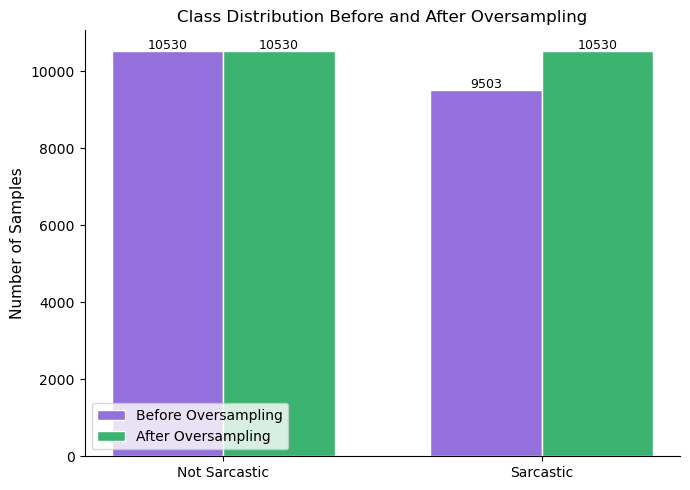

In [36]:
# Task 7B – random oversampling of the minority class

np.random.seed(seed)

majority_idx = []
minority_idx = []
for i in range(len(y_train)):
    if y_train[i] == majority:
        majority_idx.append(i)
    else:
        minority_idx.append(i)

gap       = len(majority_idx) - len(minority_idx)
extra_idx = np.random.choice(minority_idx, size=gap, replace=True)

count_train_bal = np.vstack([count_train, count_train[extra_idx]])
y_train_bal     = np.concatenate([y_train, y_train[extra_idx]])

print('class distribution after oversampling:')
print('class 0 =', int((y_train_bal == 0).sum()))
print('class 1 =', int((y_train_bal == 1).sum()))

# Class distribution before and after oversampling
labels     = ['Not Sarcastic', 'Sarcastic']
before     = [int((y_train == 0).sum()), int((y_train == 1).sum())]
after      = [int((y_train_bal == 0).sum()), int((y_train_bal == 1).sum())]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

bars1 = ax.bar(x - width/2, before, width, label='Before Oversampling', color='mediumpurple', edgecolor='white')
bars2 = ax.bar(x + width/2, after,  width, label='After Oversampling',  color='mediumseagreen', edgecolor='white')

# add count labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(bar.get_height()), ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(bar.get_height()), ha='center', fontsize=9)

ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_title('Class Distribution Before and After Oversampling', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [41]:
# Task 7C: Threshold Tuning 

log_prior_bal, log_like_bal = multinomial_nb_train(count_train_bal, y_train_bal, 0.5)

prob1 = []
for i in range(len(count_val)):
    s0 = log_prior_bal[0]
    s1 = log_prior_bal[1]
    with np.errstate(divide='ignore', invalid='ignore'):
        for j in range(count_val.shape[1]):
            s0 = s0 + count_val[i][j] * log_like_bal[0][j]
            s1 = s1 + count_val[i][j] * log_like_bal[1][j]
    top = max(s0, s1)
    e0  = np.exp(s0 - top)
    e1  = np.exp(s1 - top)
    prob1.append(e1 / (e0 + e1))
prob1 = np.array(prob1)

print('Threshold tuning on validation set:')
print()
print('threshold   accuracy   macro F1   minority F1')
print('_______________________________________________')

best_t  = 0.5
best_f1 = -1

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = []
    for p in prob1:
        if p >= t:
            preds.append(1)
        else:
            preds.append(0)
    preds = np.array(preds)

    acc = round(accuracy_score(y_val, preds), 4)
    f1m = round(f1_score(y_val, preds, average='macro'), 4)
    f1s = round(f1_score(y_val, preds, pos_label=minority), 4)
    print(f'{t}          {acc}      {f1m}       {f1s}')

    if f1m > best_f1:
        best_f1 = f1m
        best_t  = t

print()
print('best threshold =', best_t)


Threshold tuning on validation set:

threshold   accuracy   macro F1   minority F1
_______________________________________________
0.3          0.5556      0.4878       0.6741
0.4          0.5791      0.5422       0.6721
0.5          0.5989      0.5778       0.4835
0.6          0.5947      0.5478       0.4021
0.7          0.5802      0.5078       0.319

best threshold = 0.5


In [39]:
# applying best threshold 
final_preds = []
for p in prob1:
    if p >= best_t:
        final_preds.append(1)
    else:
        final_preds.append(0)
final_preds = np.array(final_preds)

cm  = confusion_matrix(y_val, final_preds)
acc = round(accuracy_score(y_val, final_preds), 4)
pre = round(precision_score(y_val, final_preds, average='macro'), 4)
rec = round(recall_score(y_val, final_preds, average='macro'), 4)
f1m = round(f1_score(y_val, final_preds, average='macro'), 4)
f1s = round(f1_score(y_val, final_preds, pos_label=minority), 4)

print('Final Validation Metrics')
print('best threshold  =', best_t)
print('accuracy        =', acc)
print('precision macro =', pre)
print('recall macro    =', rec)
print('f1 macro        =', f1m)
print('f1 minority     =', f1s)
print()
print('confusion matrix:')
print(cm)

Final Validation Metrics
best threshold  = 0.5
accuracy        = 0.5989
precision macro = 0.6141
recall macro    = 0.5938
f1 macro        = 0.5778
f1 minority     = 0.4835

confusion matrix:
[[1765  434]
 [1288  806]]


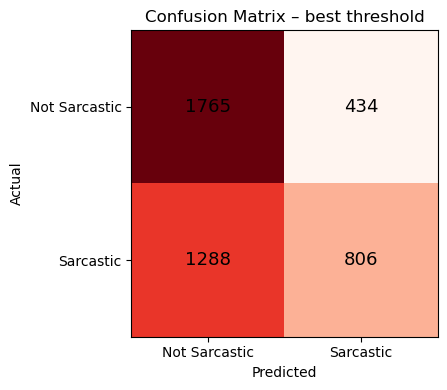

In [40]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Reds')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Sarcastic', 'Sarcastic'])
ax.set_yticklabels(['Not Sarcastic', 'Sarcastic'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – best threshold')
for r in range(2):
    for c in range(2):
        ax.text(c, r, str(cm[r][c]), ha='center', va='center', fontsize=13)
plt.tight_layout()
plt.show()

## Task 8 – Error Analysis

Looking at individual mistakes is often more informative than aggregate metrics. I picked eight misclassified headlines from the test set to examine what went wrong. I also wrote three headlines myself, one clearly sarcastic, one straightforward news, and one deliberately ambiguous and ran them through the model to see how it handles phrases it was never trained on.


In [33]:
test_preds = multinomial_nb_predict(count_test, saved_prior, saved_like)

wrong_idx = []
for i in range(len(test_preds)):
    if test_preds[i] != y_test[i]:
        wrong_idx.append(i)

print('total misclassified on test set =', len(wrong_idx))
print()
print('8 Misclassified Headlines')

for k in range(8):
    idx       = wrong_idx[k]
    headline  = test['headline'].iloc[idx]
    true_lbl  = y_test[idx]
    pred_lbl  = test_preds[idx]

    if true_lbl == 1:
        true_name = 'sarcastic'
    else:
        true_name = 'not sarcastic'

    if pred_lbl == 1:
        pred_name = 'sarcastic'
    else:
        pred_name = 'not sarcastic'

    if true_lbl == 1 and pred_lbl == 0:
        err = 'False Negative – model missed the sarcasm'
    else:
        err = 'False Positive – model wrongly predicted sarcastic'

    print(f'\n{k+1}. {headline}')
    print(f'   true: {true_name}  |  predicted: {pred_name}')
    print(f'   {err}')

total misclassified on test set = 1630

8 Misclassified Headlines

1. rain-drenched cat announces it ready to stay inside and be part of family
   true: sarcastic  |  predicted: not sarcastic
   False Negative – model missed the sarcasm

2. mother provides adult son with list of questions to ask doctor
   true: sarcastic  |  predicted: not sarcastic
   False Negative – model missed the sarcasm

3. woman builds ironclad case proving mila kunis looks bad without makeup
   true: sarcastic  |  predicted: not sarcastic
   False Negative – model missed the sarcasm

4. family assistants are the new nannies — and here's why we're absolutely on board
   true: not sarcastic  |  predicted: sarcastic
   False Positive – model wrongly predicted sarcastic

5. buzzfeed's 'try guys' tackle immigration and the results are emotional
   true: not sarcastic  |  predicted: sarcastic
   False Positive – model wrongly predicted sarcastic

6. supposed adult pays man to sit in room and listen to him talk about

In [42]:
custom_headlines = [
    ("researchers publish study on climate change effects", 0),
    ("Man in Kentucky decries influence of state in town affairs", 0),
    ("Local restaurant in Cork wins award for best mediocre food", 1),
]

print('Custom Headline Predictions')

for headline, true_label in custom_headlines:

    # step 1: clean
    text = headline.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[?!]*[!][?]+[?!]*|[?!]*[?][!]+[?!]*', '[INT_MARK]', text)
    text = re.sub(r'!{2,}', '[EXC_SEQ]', text)
    text = re.sub(r'[?]{2,}', '[QUE_SEQ]', text)
    text = re.sub(r'[.]{3,}', '[ELLIP]', text)
    text = re.sub(r"(?<=[a-z])'(?=[a-z])", 'APOS', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.replace('APOS', "'")
    word_list = re.findall(r"[\w']+|\[\w+\]", text)

    # step 2: negation handling
    after_neg = []
    tag_count = 0
    for word in word_list:
        if tag_count > 0:
            after_neg.append('NOT_' + word)
            tag_count = tag_count - 1
        elif word in negation_words:
            after_neg.append(word)
            v = 0
            for ch in word:
                if ch in 'aeiou':
                    v = v + 1
            tag_count = v
        else:
            after_neg.append(word)

    # step 3: stopword removal
    after_stop = []
    for word in after_neg:
        if word.startswith('NOT_'):
            after_stop.append(word)
        elif word not in stopwords:
            after_stop.append(word)

    # step 4: unigrams and bigrams
    final = list(after_stop)
    for k in range(len(after_stop) - 1):
        final.append(after_stop[k] + '_' + after_stop[k + 1])

    # step 5: OOV
    for k in range(len(final)):
        if final[k] not in train_vocab:
            final[k] = '<UNK>'

    # build feature vector
    vec = np.zeros(total_cols)
    for word in final:
        if word in nonprime_words_set:
            vec[0] = vec[0] + 1
        elif word in prime_words_set:
            vec[word_to_col[word]] = vec[word_to_col[word]] + 1

    # predicting using saved multinomial NB
    s0 = saved_prior[0]
    s1 = saved_prior[1]
    for j in range(total_cols):
        s0 = s0 + vec[j] * saved_like[0][j]
        s1 = s1 + vec[j] * saved_like[1][j]

    if s1 > s0:
        pred = 1
    else:
        pred = 0

    if true_label == 1:
        true_name = 'sarcastic'
    else:
        true_name = 'not sarcastic'

    if pred == 1:
        pred_name = 'sarcastic'
    else:
        pred_name = 'not sarcastic'

    if pred == true_label:
        correct = 'CORRECT'
    else:
        correct = 'WRONG'

    print(f'\nHeadline  : {headline}')
    print(f'Expected  : {true_name}')
    print(f'Predicted : {pred_name}  [{correct}]')

Custom Headline Predictions

Headline  : researchers publish study on climate change effects
Expected  : not sarcastic
Predicted : not sarcastic  [CORRECT]

Headline  : Man in Kentucky decries influence of state in town affairs
Expected  : not sarcastic
Predicted : not sarcastic  [CORRECT]

Headline  : Local restaurant in Cork wins award for best mediocre food
Expected  : sarcastic
Predicted : not sarcastic  [WRONG]


In [43]:
# Final Model Summary 
print('FINAL MODEL RESULTS SUMMARY')

print('\n── Task 3: Text-Based Naïve Bayes (Validation Set) ─────')
mnb_preds = multinomial_nb_predict(count_val, saved_prior, saved_like)
mnb_acc = round(accuracy_score(y_val, mnb_preds), 4)
mnb_f1  = round(f1_score(y_val, mnb_preds, average='macro'), 4)
print(f'  Multinomial NB   acc = {mnb_acc}   macro F1 = {mnb_f1}')

bnb_preds = bernoulli_nb_predict(count_val, saved_b_prior, saved_b_yes, saved_b_no)
bnb_acc = round(accuracy_score(y_val, bnb_preds), 4)
bnb_f1  = round(f1_score(y_val, bnb_preds, average='macro'), 4)
print(f'  Bernoulli NB     acc = {bnb_acc}   macro F1 = {bnb_f1}')

print('\n── Task 3: Text-Based Naïve Bayes (Test Set) ───────────')
test_preds_mnb = multinomial_nb_predict(count_test, saved_prior, saved_like)
test_mnb_acc = round(accuracy_score(y_test, test_preds_mnb), 4)
test_mnb_f1  = round(f1_score(y_test, test_preds_mnb, average='macro'), 4)
print(f'  Multinomial NB   acc = {test_mnb_acc}   macro F1 = {test_mnb_f1}')

test_preds_bnb = bernoulli_nb_predict(count_test, saved_b_prior, saved_b_yes, saved_b_no)
test_bnb_acc = round(accuracy_score(y_test, test_preds_bnb), 4)
test_bnb_f1  = round(f1_score(y_test, test_preds_bnb, average='macro'), 4)
print(f'  Bernoulli NB     acc = {test_bnb_acc}   macro F1 = {test_bnb_f1}')

print('\n── Task 6: Gaussian NB on Numeric Features (Validation) ─')
gnb_mm_preds = gaussian_nb_predict(num_val_minmax, gnb_prior_mm, gnb_mean_mm, gnb_var_mm)
mm_acc = round(accuracy_score(y_val, gnb_mm_preds), 4)
mm_f1  = round(f1_score(y_val, gnb_mm_preds, average='macro'), 4)
print(f'  Gaussian NB (MinMax)      acc = {mm_acc}   macro F1 = {mm_f1}')

gnb_std_preds = gaussian_nb_predict(num_val_std, gnb_prior_std, gnb_mean_std, gnb_var_std)
std_acc = round(accuracy_score(y_val, gnb_std_preds), 4)
std_f1  = round(f1_score(y_val, gnb_std_preds, average='macro'), 4)
print(f'  Gaussian NB (Standardise) acc = {std_acc}   macro F1 = {std_f1}')

print('\n── Task 6: Gaussian NB on Numeric Features (Test Set) ───')
gnb_mm_test = gaussian_nb_predict(num_test_minmax, gnb_prior_mm, gnb_mean_mm, gnb_var_mm)
mm_test_acc = round(accuracy_score(y_test, gnb_mm_test), 4)
mm_test_f1  = round(f1_score(y_test, gnb_mm_test, average='macro'), 4)
print(f'  Gaussian NB (MinMax)      acc = {mm_test_acc}   macro F1 = {mm_test_f1}')

gnb_std_test = gaussian_nb_predict(num_test_std, gnb_prior_std, gnb_mean_std, gnb_var_std)
std_test_acc = round(accuracy_score(y_test, gnb_std_test), 4)
std_test_f1  = round(f1_score(y_test, gnb_std_test, average='macro'), 4)
print(f'  Gaussian NB (Standardise) acc = {std_test_acc}   macro F1 = {std_test_f1}')

print('\n── Task 7: Oversampled + Threshold-Tuned (Validation) ───')
print(f'  best threshold  = {best_t}')
print(f'  accuracy        = {round(accuracy_score(y_val, final_preds), 4)}')
print(f'  macro F1        = {round(f1_score(y_val, final_preds, average="macro"), 4)}')
print(f'  minority F1     = {round(f1_score(y_val, final_preds, pos_label=minority), 4)}')

print('\n── Task 8: Test Set Final Evaluation ────────────────────')
test_preds_final = multinomial_nb_predict(count_test, saved_prior, saved_like)
test_final_acc = round(accuracy_score(y_test, test_preds_final), 4)
test_final_f1  = round(f1_score(y_test, test_preds_final, average='macro'), 4)
cm = confusion_matrix(y_test, test_preds_final)
print(f'  Accuracy         = {test_final_acc}')
print(f'  Macro F1         = {test_final_f1}')
print(f'  Confusion Matrix:')
print(f'    TN={cm[0][0]}  FP={cm[0][1]}')
print(f'    FN={cm[1][0]}  TP={cm[1][1]}')
print(f'  Precision = {round(precision_score(y_test, test_preds_final), 4)}')
print(f'  Recall    = {round(recall_score(y_test, test_preds_final), 4)}')
print(f'  F1 (minority) = {round(f1_score(y_test, test_preds_final, pos_label=1), 4)}')


FINAL MODEL RESULTS SUMMARY

── Task 3: Text-Based Naïve Bayes (Validation Set) ─────
  Multinomial NB   acc = 0.5998   macro F1 = 0.5747
  Bernoulli NB     acc = 0.6007   macro F1 = 0.5774

── Task 3: Text-Based Naïve Bayes (Test Set) ───────────
  Multinomial NB   acc = 0.6203   macro F1 = 0.5945
  Bernoulli NB     acc = 0.6198   macro F1 = 0.5952

── Task 6: Gaussian NB on Numeric Features (Validation) ─
  Gaussian NB (MinMax)      acc = 0.6599   macro F1 = 0.6554
  Gaussian NB (Standardise) acc = 0.6599   macro F1 = 0.6554

── Task 6: Gaussian NB on Numeric Features (Test Set) ───
  Gaussian NB (MinMax)      acc = 0.6567   macro F1 = 0.6516
  Gaussian NB (Standardise) acc = 0.6567   macro F1 = 0.6516

── Task 7: Oversampled + Threshold-Tuned (Validation) ───
  best threshold  = 0.5
  accuracy        = 0.5989
  macro F1        = 0.5778
  minority F1     = 0.4835

── Task 8: Test Set Final Evaluation ────────────────────
  Accuracy         = 0.6203
  Macro F1         = 0.5945
  Confu